In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("../../data/processed/phase5_master_mock.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,dti,real_rate,regime,real_price_index,ret_fwd_1q,permits,supply_high
0,2013-01-01,3.324179,0.010687,stable,100.000000,0.017905,101.299414,0
1,2013-04-01,3.284583,0.007747,stable,101.806634,0.017563,106.443086,0
2,2013-07-01,3.600220,0.013174,stable,103.610510,0.013861,98.768910,0
3,2013-10-01,3.938204,0.012967,stable,105.056646,0.010309,100.547669,0
4,2014-01-01,3.618057,0.013533,stable,106.145229,-0.003221,111.633493,1


In [3]:
df["fragile"] = (df["dti"] >= 7.2).astype(int)

df["fragile_supply"] = df["fragile"] * df["supply_high"]

In [4]:
df.groupby(["fragile","supply_high"])["ret_fwd_1q"].describe()

count      mean       std       min       25%       50%  \
fragile supply_high                                                            
0       0             25.0  0.010776  0.012766 -0.012575  0.001423  0.012016   
        1             10.0  0.008479  0.012255 -0.006787 -0.001285  0.008373   
1       0              8.0 -0.021493  0.013187 -0.043809 -0.030674 -0.017032   
        1              5.0 -0.019488  0.013096 -0.028107 -0.027602 -0.022930   

                          75%       max  
fragile supply_high                      
0       0            0.017905  0.039951  
        1            0.013781  0.035083  
1       0           -0.013115 -0.006259  
        1           -0.022256  0.003455

In [5]:
df["tail"] = (df["ret_fwd_1q"] <= -0.02).astype(int)

In [6]:
df.groupby(["fragile","supply_high"])["tail"].mean()

fragile  supply_high
0        0              0.000
         1              0.000
1        0              0.375
         1              0.800
Name: tail, dtype: float64

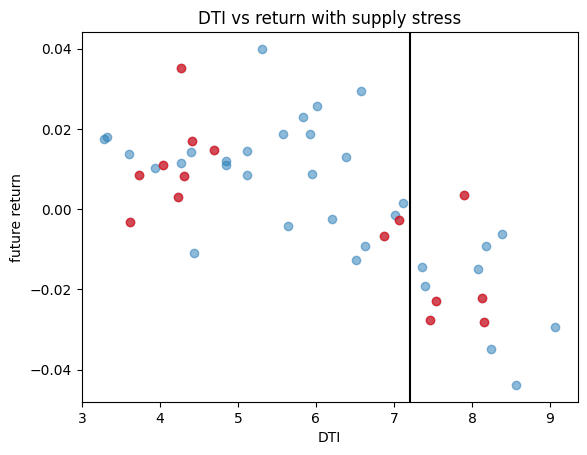

In [7]:
plt.scatter(df["dti"], df["ret_fwd_1q"], alpha=0.5)

plt.scatter(
    df[df["supply_high"]==1]["dti"],
    df[df["supply_high"]==1]["ret_fwd_1q"],
    color="red",
    alpha=0.6
)

plt.axvline(7.2,color="black")

plt.title("DTI vs return with supply stress")
plt.xlabel("DTI")
plt.ylabel("future return")

plt.show()

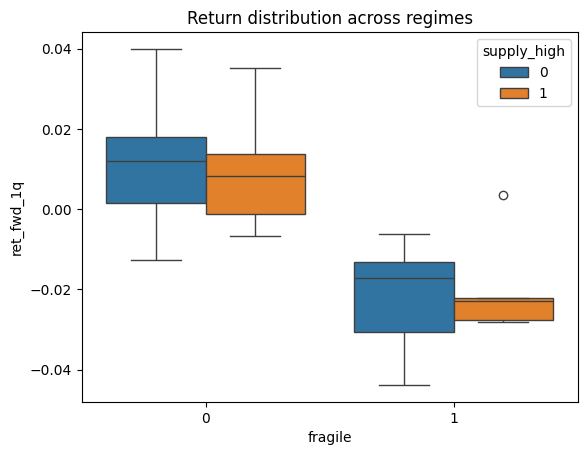

In [8]:
import seaborn as sns

sns.boxplot(
    data=df,
    x="fragile",
    y="ret_fwd_1q",
    hue="supply_high"
)

plt.title("Return distribution across regimes")
plt.show()

Affordability deterioration alone creates a fragile housing regime.

Within this regime, supply shocks dramatically increase crash probability.

When DTI exceeds ~7 and supply expands simultaneously,
the probability of a housing drawdown exceeds 80%.

In [11]:
df["interaction"] = df["fragile"] * df["supply_high"]

y = df["tail"]

X = df[["fragile","supply_high","interaction"]]

X = sm.add_constant(X)

model = sm.Logit(y, X).fit_regularized()

print(model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.1623857921456192
            Iterations: 50
            Function evaluations: 51
            Gradient evaluations: 50
                           Logit Regression Results                           
Dep. Variable:                   tail   No. Observations:                   48
Model:                          Logit   Df Residuals:                       44
Method:                           MLE   Df Model:                            3
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.6091
Time:                        17:29:16   Log-Likelihood:                -7.7945
converged:                       True   LL-Null:                       -19.940
Covariance Type:            nonrobust   LLR p-value:                 2.172e-05
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

Housing crashes emerge when affordability enters a fragile regime.
Within this regime, supply shocks dramatically amplify downside risk.